# 02 — CMIP6 Multi-Model Climate Projections

**The thesis of this notebook**: a single climate model's line is an opinion; the multi-model *range* is the finding.

> **CMIP6** — the Coupled Model Intercomparison Project, phase 6: a coordinated effort in which independent research groups worldwide run their own climate models over agreed scenarios, precisely so the models can be compared. Open-Meteo's Climate API serves a set of downscaled high-resolution (HighResMIP) runs at ~25 km — coarser than ERA5's ~9 km.

> **Projection ≠ forecast** — a forecast starts from today's observed atmosphere and predicts specific weather. A projection is driven by *scenario* boundary conditions (greenhouse-gas trajectories) and makes no claim about any particular year: its year-to-year wiggles are internal model variability, not predictions.

**Goal**: Exercise the client's multi-model parsing end-to-end, quality-check CMIP6 data per model, and quantify how much the models agree — and disagree — about the climate of two agricultural regions through 2050.

**Endpoint**: Climate API (CMIP6 projections, 1950–2050)

**Locations** (same two as [notebook 01](01-open-meteo-exploration.ipynb), for continuity):
- Pampa, Argentina (-34.6, -58.4) — major grain production region
- Midwest, USA (41.9, -89.1) — US corn belt

**Models** (the client's defaults):
- `EC_Earth3P_HR` — EC-Earth consortium (EU)
- `MRI_AGCM3_2_S` — Meteorological Research Institute (Japan)
- `FGOALS_f3_H` — Chinese Academy of Sciences

**How to read this notebook**: as in notebook 01, each section states its expectation before the figure and interprets after. The canonical quality record lives in [`docs/data-quality-report.md`](../docs/data-quality-report.md).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from pretaverdi.client import get_climate_projections, get_historical_weather
from pretaverdi.variables import CLIMATE_DEFAULT_MODELS, LOCATIONS

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

## 1. Fetch Projections — Three Models, One Request

We request 36 years (2015–2050) of daily projections for all three default models in a single call per location. The API returns one response message per model; the client assembles them into a frame with `(variable, model)` MultiIndex columns, verifying the returned model labels against the request.

*Reproducibility note*: these are large requests — Open-Meteo weighs calls by data volume, and a fresh run can hit the free tier's per-minute limit ("Minutely API request limit exceeded"). Wait a minute and re-run; responses are cached locally for 1 h.

In [2]:
MODELS = CLIMATE_DEFAULT_MODELS
START, END = "2015-01-01", "2050-12-31"

pampa = LOCATIONS["pampa_ar"]
proj_pampa = get_climate_projections(pampa["lat"], pampa["lon"], START, END)
print(f"Pampa shape: {proj_pampa.shape}")
proj_pampa.head()

Pampa shape: (13149, 9)


variable                  temperature_2m_max                            \
model                          EC_Earth3P_HR MRI_AGCM3_2_S FGOALS_f3_H   
date                                                                     
2015-01-01 03:00:00+00:00          26.291927     23.350990   26.756641   
2015-01-02 03:00:00+00:00          27.539232     25.456821   27.775154   
2015-01-03 03:00:00+00:00          27.986628     29.313959   26.038630   
2015-01-04 03:00:00+00:00          28.984024     28.721100   23.752108   
2015-01-05 03:00:00+00:00          29.381420     31.578238   25.065584   

variable                  temperature_2m_min                            \
model                          EC_Earth3P_HR MRI_AGCM3_2_S FGOALS_f3_H   
date                                                                     
2015-01-01 03:00:00+00:00          18.006268     22.842640   21.656164   
2015-01-02 03:00:00+00:00          18.905479     17.190125   20.632351   
2015-01-03 03:00:00+00:00          19.604902     21.236761   17.854511   
2015-01-04 03:00:00+00:00          20.004320     22.183392   18.626671   
2015-01-05 03:00:00+00:00          20.253744     22.830027   17.498831   

variable                  precipitation_sum                            
model                         EC_Earth3P_HR MRI_AGCM3_2_S FGOALS_f3_H  
date                                                                   
2015-01-01 03:00:00+00:00               0.0      8.823085    0.602162  
2015-01-02 03:00:00+00:00               0.0      0.000000   59.419655  
2015-01-03 03:00:00+00:00               0.0      0.000000    0.000000  
2015-01-04 03:00:00+00:00               0.0      0.000000    0.000000  
2015-01-05 03:00:00+00:00               0.0      0.000000    0.000000

In [3]:
midwest = LOCATIONS["midwest_us"]
proj_midwest = get_climate_projections(midwest["lat"], midwest["lon"], START, END)
print(f"Midwest shape: {proj_midwest.shape}")
proj_midwest.head()

Midwest shape: (13149, 9)


variable                  temperature_2m_max                            \
model                          EC_Earth3P_HR MRI_AGCM3_2_S FGOALS_f3_H   
date                                                                     
2015-01-01 05:00:00+00:00          -0.114647      1.768735    1.534968   
2015-01-02 05:00:00+00:00           4.785588      3.933351    1.517399   
2015-01-03 05:00:00+00:00           3.985874      2.049012   -0.150496   
2015-01-04 05:00:00+00:00           5.236160     -0.735326    0.981609   
2015-01-05 05:00:00+00:00          10.786447      2.180337    0.713713   

variable                  temperature_2m_min                            \
model                          EC_Earth3P_HR MRI_AGCM3_2_S FGOALS_f3_H   
date                                                                     
2015-01-01 05:00:00+00:00          -9.651465     -4.642940   -0.791112   
2015-01-02 05:00:00+00:00          -2.004561     -1.779431   -1.215542   
2015-01-03 05:00:00+00:00          -3.557615     -3.964112   -3.689734   
2015-01-04 05:00:00+00:00          -0.760669     -4.948793   -3.313925   
2015-01-05 05:00:00+00:00           4.236277     -4.933474   -2.588115   

variable                  precipitation_sum                            
model                         EC_Earth3P_HR MRI_AGCM3_2_S FGOALS_f3_H  
date                                                                   
2015-01-01 05:00:00+00:00          0.000000      0.000000    2.772555  
2015-01-02 05:00:00+00:00          0.172717      2.920825    0.213851  
2015-01-03 05:00:00+00:00          0.518593      0.291708    0.000000  
2015-01-04 05:00:00+00:00          1.643602      0.194225    0.000000  
2015-01-05 05:00:00+00:00         22.337177      0.096990    1.186762

Each frame is dates × (3 variables × 3 models). The MultiIndex makes ensemble operations one-liners: `proj_pampa["temperature_2m_max"]` selects a date × models frame, so row-wise `min`/`mean`/`max` across it *is* the model spread. A single-model call would return the flat shape of notebook 01.

## 2. Per-Model Quality Check

In multi-model data, *missingness is a per-model property*: one model can silently lack a variable that another provides. A quality check run on the frame as a whole would average the problem away — so we group every check by model.

In [4]:
print(f"Rows per frame: {len(proj_pampa)} (daily, 2015–2050)")

ec_nan = proj_pampa[("temperature_2m_max", "EC_Earth3P_HR")].isna()
print(f"EC_Earth3P_HR NaN dates: {proj_pampa.index[ec_nan].min():%Y-%m-%d} "
      f"→ {proj_pampa.index[ec_nan].max():%Y-%m-%d} ({ec_nan.sum()} days)")

nulls = pd.concat(
    {"Pampa": proj_pampa.isna().mean(), "Midwest": proj_midwest.isna().mean()},
    axis=1,
).mul(100).round(1)
nulls.index.names = ["variable", "model"]
nulls.columns.name = "% NaN"
nulls

Rows per frame: 13149 (daily, 2015–2050)
EC_Earth3P_HR NaN dates: 2050-01-01 → 2050-12-31 (365 days)


% NaN                             Pampa  Midwest
variable           model                        
temperature_2m_max EC_Earth3P_HR    2.8      2.8
                   MRI_AGCM3_2_S    0.0      0.0
                   FGOALS_f3_H      0.0      0.0
temperature_2m_min EC_Earth3P_HR    2.8      2.8
                   MRI_AGCM3_2_S    0.0      0.0
                   FGOALS_f3_H      0.0      0.0
precipitation_sum  EC_Earth3P_HR    2.8      2.8
                   MRI_AGCM3_2_S    0.0      0.0
                   FGOALS_f3_H      0.0      0.0

The check earns its keep on its first table: `EC_Earth3P_HR` carries 2.8% NaN in *every* variable at both locations — exactly one year's worth, and the printed dates show why: its record simply ends in 2049, while the other two models run through 2050. Averaged over the ensemble this would have been invisible.

NaN is only the *explicit* form of missing, though. A subtler failure mode is missing data disguised as zeros — harmless in a temperature mean, catastrophic in a precipitation sum. A cheap plausibility floor: no year at either of these sites should total less than 300 mm.

In [5]:
def annual_precipitation(df):
    """Annual totals per model; partial years (<300 valid days) and
    implausibly dry years (<300 mm) are masked as missing."""
    annual = df["precipitation_sum"].resample("YE").sum(min_count=300)
    annual.index = annual.index.year
    return annual.mask(annual < 300)


for name, df in [("Pampa", proj_pampa), ("Midwest", proj_midwest)]:
    raw = df["precipitation_sum"].resample("YE").sum(min_count=300)
    raw.index = raw.index.year
    flagged = raw[(raw < 300).any(axis=1)]
    print(f"=== {name} — implausibly dry years (<300 mm), raw totals ===")
    print(flagged.round(0).to_string(), "\n")

fgoals_2016 = proj_pampa[("precipitation_sum", "FGOALS_f3_H")]["2016"]
print(f"FGOALS_f3_H 2016 at Pampa: {(fgoals_2016 == 0).sum()}/{len(fgoals_2016)} days are exactly 0 mm")

=== Pampa — implausibly dry years (<300 mm), raw totals ===
model  EC_Earth3P_HR  MRI_AGCM3_2_S  FGOALS_f3_H
date                                            
2016          1029.0         1145.0        160.0 

=== Midwest — implausibly dry years (<300 mm), raw totals ===
model  EC_Earth3P_HR  MRI_AGCM3_2_S  FGOALS_f3_H
date                                            
2016           891.0          890.0         31.0 

FGOALS_f3_H 2016 at Pampa: 350/366 days are exactly 0 mm


Caught: `FGOALS_f3_H`'s 2016 is zero on 350 of 366 days at *both* sites — annual totals of 160 mm (Pampa) and 31 mm (Midwest) that no NaN check would ever flag. `annual_precipitation()` treats such years as missing, and its `min_count` guard also handles `EC_Earth3P_HR`'s phantom 2050: summing an all-NaN year would otherwise return 0, not NaN. Every precipitation analysis below uses this cleaned form.

### 2.1 Exhibit: Why Soil Moisture Is Not a Default

A third, starker case of per-model missingness. We request `soil_moisture_0_to_10cm_mean` — the Climate API's daily soil band — for all three models over a single year.

In [6]:
soil = get_climate_projections(
    pampa["lat"], pampa["lon"], "2020-01-01", "2020-12-31",
    variables=["soil_moisture_0_to_10cm_mean"],
)
soil["soil_moisture_0_to_10cm_mean"].isna().mean().mul(100).round(1).rename("% NaN").to_frame()

,% NaN
model,
EC_Earth3P_HR,100.0
MRI_AGCM3_2_S,0.0
FGOALS_f3_H,100.0


Two of the three models return a 100% null series — and the API returns it *without any error*. An all-null series is indistinguishable from success unless you check. This is the concrete reason `CLIMATE_DEFAULTS` excludes soil moisture (see the comment in [`src/pretaverdi/variables.py`](../src/pretaverdi/variables.py) and the quality report), and the general lesson of this section: quality-check every model separately, because the ensemble hides per-model gaps.

## 3. The Key Figure: Multi-Model Temperature Spread

We aggregate daily values to *annual means* of (T max + T min) / 2 — climate is the signal that survives once weather noise is averaged out. The figure's grammar: one thin line per model, and a shaded band spanning the per-year min–max across models. Expectation: the models agree on the *direction* of change but disagree on its *magnitude* — the band should be visibly wide and should not collapse over time.

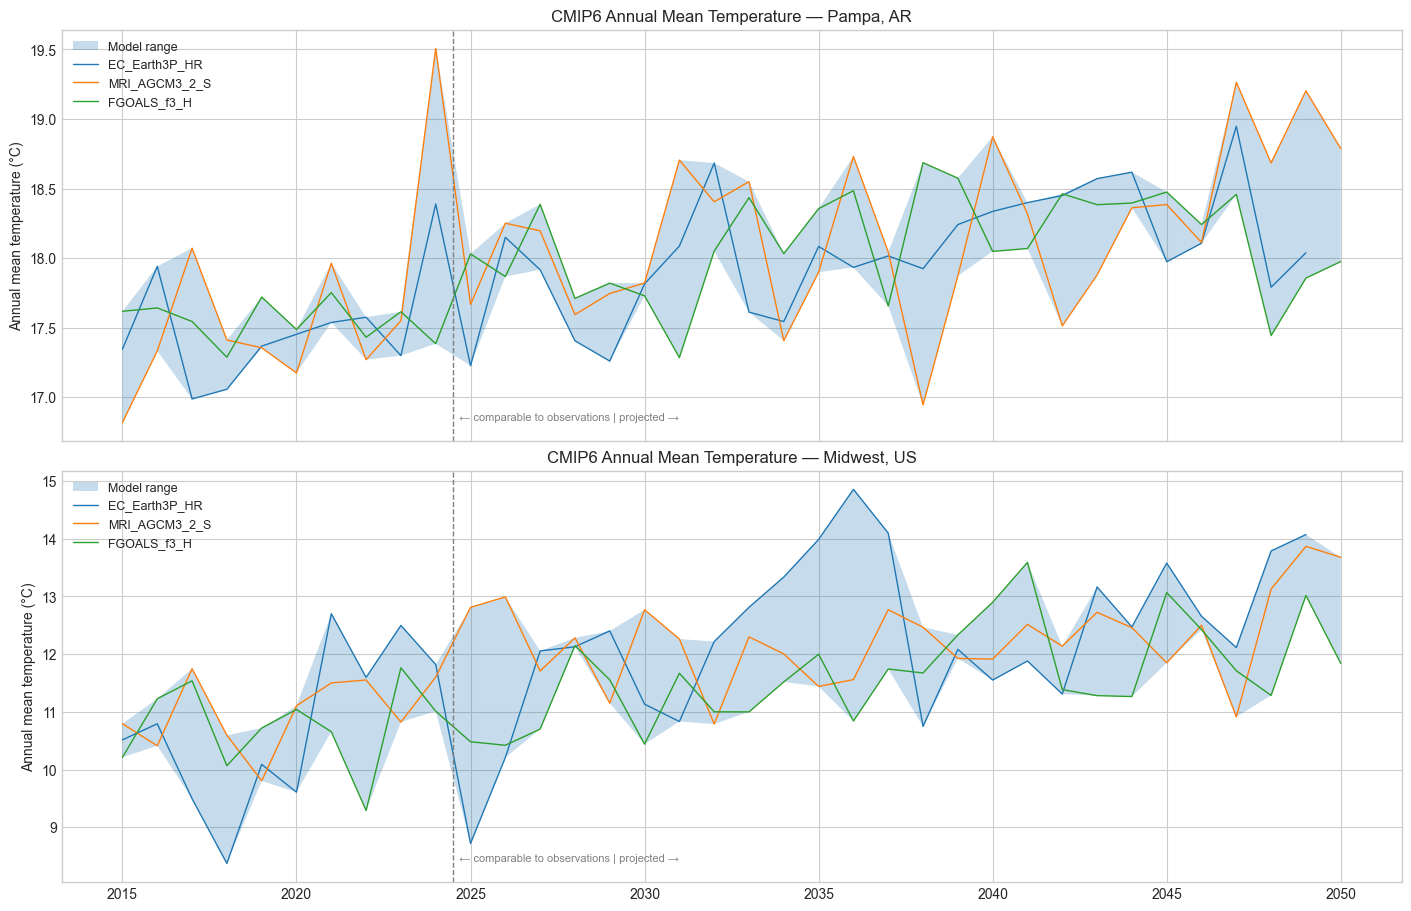

In [7]:
def annual_mean_temperature(df):
    """Annual mean of (tmax + tmin) / 2 per model, indexed by year."""
    tmean = (df["temperature_2m_max"] + df["temperature_2m_min"]) / 2
    annual = tmean.resample("YE").mean()
    annual.index = annual.index.year
    return annual


fig, axes = plt.subplots(2, 1, figsize=(14, 9), layout="constrained", sharex=True)

for ax, df, name in [(axes[0], proj_pampa, "Pampa, AR"), (axes[1], proj_midwest, "Midwest, US")]:
    annual = annual_mean_temperature(df)
    ax.fill_between(
        annual.index, annual.min(axis=1), annual.max(axis=1),
        alpha=0.25, label="Model range",
    )
    for model in MODELS:
        ax.plot(annual.index, annual[model], linewidth=1, label=model)
    ax.axvline(2024.5, color="gray", linestyle="--", linewidth=1)
    ax.text(2024.5, annual.min(axis=1).min(), "  ← comparable to observations | projected →",
            fontsize=8, color="gray", va="bottom")
    ax.set_ylabel("Annual mean temperature (°C)")
    ax.set_title(f"CMIP6 Annual Mean Temperature — {name}")
    ax.legend(loc="upper left", fontsize=9)

plt.show()

Direction unanimous, magnitude not: all three models warm both regions through 2050, with the Midwest warming roughly twice as fast as Pampa. The band stays visibly wide the whole way — that width is *structural* uncertainty: disagreement between equally defensible models given the same scenario. Two honest details. No single year on any line is a prediction (the wiggles are internal model variability). And §2's lesson is visible here: `EC_Earth3P_HR`'s line stops a year short — its record ends in 2049.

### 3.2 Precipitation Spread

Same grammar, annual *totals* this time — the cleaned totals from §2's `annual_precipitation()`, not raw sums. Expectation: a messier picture — precipitation is where climate models disagree most, a canonical result of climate modeling. Warming is thermodynamically constrained; where and when it rains depends on circulation details each model resolves differently.

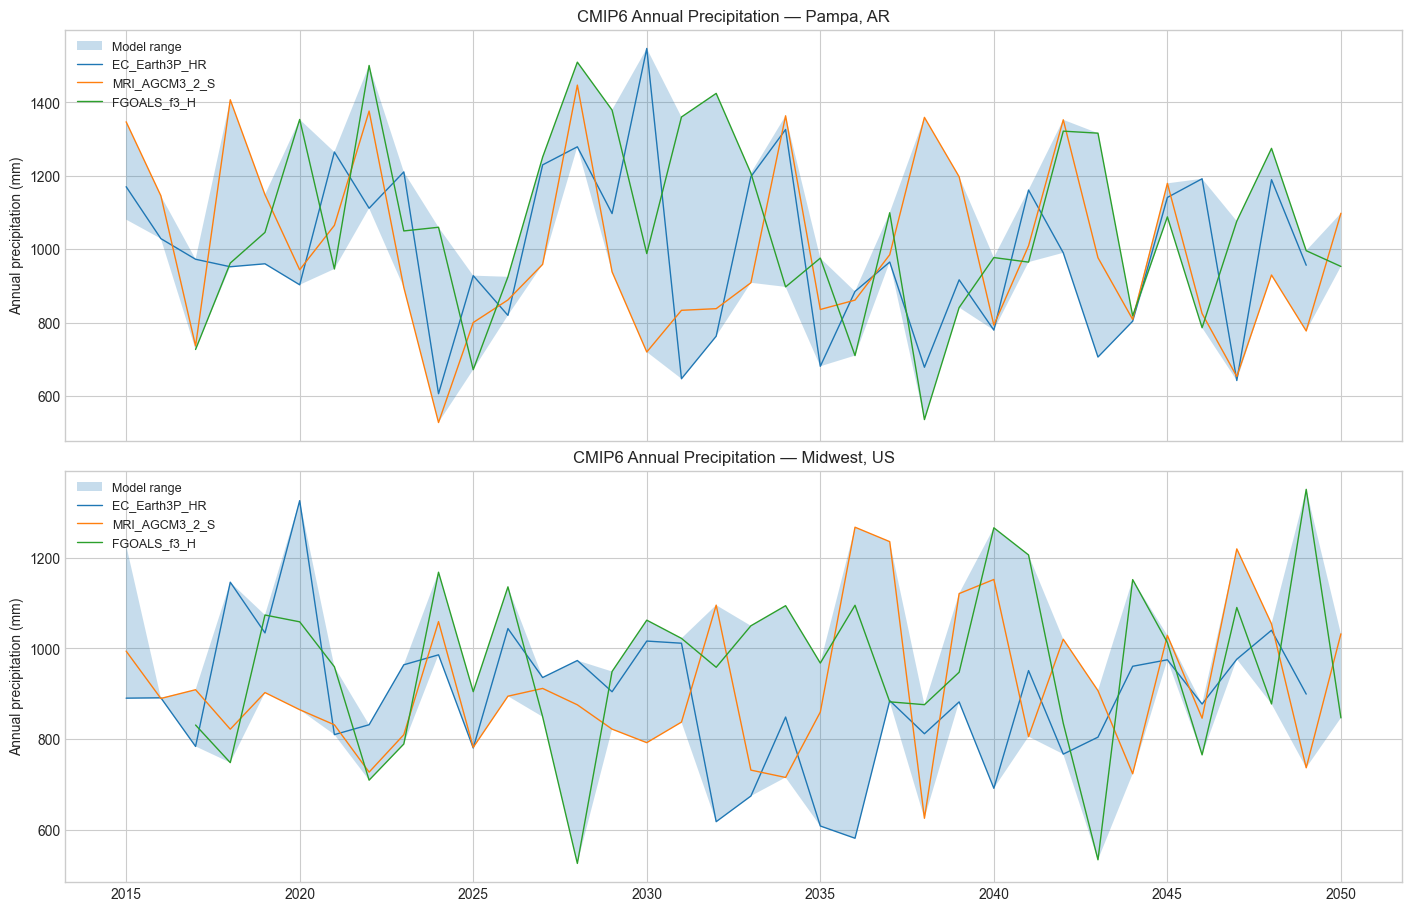

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), layout="constrained", sharex=True)

for ax, df, name in [(axes[0], proj_pampa, "Pampa, AR"), (axes[1], proj_midwest, "Midwest, US")]:
    annual = annual_precipitation(df)
    ax.fill_between(
        annual.index, annual.min(axis=1), annual.max(axis=1),
        alpha=0.25, label="Model range",
    )
    for model in MODELS:
        ax.plot(annual.index, annual[model], linewidth=1, label=model)
    ax.set_ylabel("Annual precipitation (mm)")
    ax.set_title(f"CMIP6 Annual Precipitation — {name}")
    ax.legend(loc="upper left", fontsize=9)

plt.show()

Messier, as predicted: the envelopes stay wide and overlapping across the whole window, and no model's line separates from the pack for long — where temperature showed a drift you can see, precipitation shows disagreement you can't miss. The two §2 artifacts are visible here as *gaps*, not lies: `EC_Earth3P_HR`'s line ends in 2049 and `FGOALS_f3_H`'s 2016 is masked out. Unmasked, both would have plotted as spikes to zero. The quantitative verdict comes next.

## 4. Quantifying Disagreement

The pictures suggest agreement on warming and disagreement on precipitation; now we put numbers on it. For each location and variable we compare two decades — 2015–2024 vs 2041–2050 — per model. The per-model *change* is the signal; the max−min across models' changes (the `spread` column) is the structural disagreement. When the spread is comparable to the signal, no single model's number deserves to be quoted alone.

In [9]:
def decadal_change(df, location):
    """Per-model change between the 2015-2024 and 2041-2050 decades."""
    rows = {}
    for label, annual in [
        ("t_mean (°C)", annual_mean_temperature(df)),
        ("precip (mm/yr)", annual_precipitation(df)),
    ]:
        early = annual[annual.index <= 2024].mean()
        late = annual[annual.index >= 2041].mean()
        delta = (late - early).round(1)
        rows[(location, label)] = {
            **delta.to_dict(),
            "spread": round(delta.max() - delta.min(), 1),
        }
    return rows


summary = pd.DataFrame.from_dict(
    {**decadal_change(proj_pampa, "Pampa"), **decadal_change(proj_midwest, "Midwest")},
    orient="index",
)
summary.index.names = ["location", "variable"]
summary

EC_Earth3P_HR  MRI_AGCM3_2_S  FGOALS_f3_H      spread
location variable                                                             
Pampa    t_mean (°C)          0.800000       0.800000          0.6    0.200000
         precip (mm/yr)     -42.200001     -98.400002        -21.0   77.400002
Midwest  t_mean (°C)          2.000000       1.600000          1.3    0.700000
         precip (mm/yr)     -49.599998      56.500000         15.4  106.099998

Temperature change is robust: Pampa warms +0.6 to +0.8 °C (a spread of 0.2 °C — a quarter of the signal), the Midwest +1.3 to +2.0 °C (spread 0.7 °C, about a third). Precipitation is where the thesis bites: at Pampa all three models lean dry (−21 to −98 mm/yr) but the spread (77 mm/yr) exceeds the central estimate, and at the Midwest the models do not even agree on the *sign* (−50 to +57 mm/yr, spread 106).

A meta-lesson, earned the hard way: computed on the **raw** data, this same table showed Pampa's models disagreeing in sign too — entirely an artifact of `FGOALS_f3_H`'s zero-2016 inflating its early-decade change (+71 instead of −21) and `EC_Earth3P_HR`'s phantom 2050 deflating its late decade (−140 instead of −42). Two data-quality fixes changed a qualitative conclusion. (Caveat that remains: `EC_Earth3P_HR`'s late decade is effectively 2041–2049.)

## 5. Hindcast Reality Check

The 2015–2024 decade exists in both worlds: projected by the models and observed by ERA5 (notebook 01's reanalysis). Overlaying them shows how far each model's *level* sits from reality.

Two rules keep this comparison honest. First, HighResMIP runs are not initialized from observations — their year-to-year wiggles *cannot and should not* match ERA5's; only the mean level is comparable. Second, the grids differ (~25 km vs ~9 km), so part of any offset is representativeness, not error.

> **Bias** — a systematic offset of a model against a reference. Bias does not disqualify a model: it is measured, then corrected for, before absolute thresholds (frost, heat stress) are computed from projections.

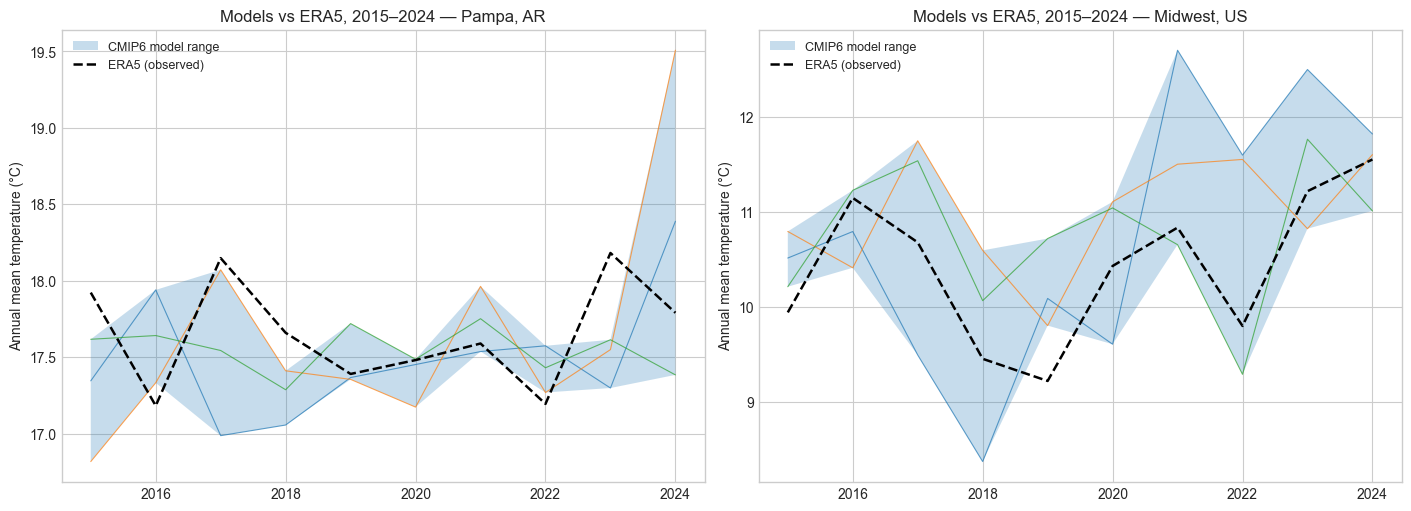

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), layout="constrained")

for ax, loc, proj, name in [
    (axes[0], pampa, proj_pampa, "Pampa, AR"),
    (axes[1], midwest, proj_midwest, "Midwest, US"),
]:
    era = get_historical_weather(
        loc["lat"], loc["lon"], "2015-01-01", "2024-12-31",
        variables=["temperature_2m_max", "temperature_2m_min"],
    )
    era_annual = ((era["temperature_2m_max"] + era["temperature_2m_min"]) / 2).resample("YE").mean()
    era_annual.index = era_annual.index.year

    recent = annual_mean_temperature(proj).loc[:2024]
    ax.fill_between(
        recent.index, recent.min(axis=1), recent.max(axis=1),
        alpha=0.25, label="CMIP6 model range",
    )
    for model in MODELS:
        ax.plot(recent.index, recent[model], linewidth=0.8, alpha=0.7)
    ax.plot(era_annual.index, era_annual, "k--", linewidth=1.8, label="ERA5 (observed)")
    ax.set_ylabel("Annual mean temperature (°C)")
    ax.set_title(f"Models vs ERA5, 2015–2024 — {name}")
    ax.legend(loc="upper left", fontsize=9)

plt.show()

The levels land remarkably close to reality. Over 2015–2024, ERA5 averages 17.65 °C at Pampa against model decade-means of 17.49–17.64 °C — biases under 0.2 °C. The Midwest runs slightly warm in every model (10.75–10.99 °C vs ERA5's 10.43 °C: a +0.3 to +0.6 °C bias). Year by year, the picture is exactly what the setup predicted: ERA5 weaves in and out of the model envelope (inside it in 40% of years at Pampa, 80% at the Midwest), because uninitialized runs cannot — and should not — track observed years. Practical consequence: anomaly-based indicators can consume these projections directly; absolute-threshold indicators (frost days, heat stress) need the bias corrected first.

## 6. Findings & Limitations

### Findings
- **Multi-model parsing works end-to-end**: one 36-year request per location returns all three models, labeled via the response metadata and shape-verified, as `(variable, model)` columns.
- **Even "complete" models differ in temporal coverage**: `EC_Earth3P_HR` ends in 2049 — a full year of NaNs (2.8% of the window) that only a per-model check catches.
- **Missingness can be disguised as zeros**: `FGOALS_f3_H`'s 2016 is 350/366 zero-precipitation days at both sites (annual totals of 160 mm and 31 mm) — invisible to NaN checks, caught by a plausibility floor, masked in every analysis here.
- **Soil moisture reproduces its documented gap**: 100% null for `EC_Earth3P_HR` and `FGOALS_f3_H`, full data for `MRI_AGCM3_2_S` — and the API returns the null series without error.
- **Warming is robust, precipitation is not**: temperature change agrees in sign and roughly in magnitude at both sites (inter-model spread ≤ ~35% of the signal); cleaned precipitation change leans dry at Pampa (−21 to −98 mm/yr) but disagrees *in sign* at the Midwest (−50 to +57 mm/yr), with spreads comparable to or exceeding the signal.
- **Data quality changes conclusions**: on raw data, the decadal table showed sign disagreement at Pampa too — created entirely by the two coverage artifacts above.
- **Bias vs ERA5 is small but real**: under 0.2 °C at Pampa, +0.3–0.6 °C warm at the Midwest, over 2015–2024.

### Limitations
- Open-Meteo serves **one downscaling chain and one scenario** per model — this is a slice of CMIP6, not the full ensemble; the true structural uncertainty is wider than shown here
- **Three models is a small sample** of model diversity; the min–max band is a floor on the uncertainty, not a confidence interval
- ~25 km resolution — regional averages only, no field-level signal
- **Annual means hide extremes** — heat waves, frosts and dry spells matter more to agriculture than the mean, and need daily-scale indicators
- **No bias correction applied** — absolute values should not feed thresholds until §5's offsets are corrected for

### Decision Gate

**Decision: risk-indicator prototyping must consume the ensemble *range*, never a single model's trajectory.**

The warming signal is robust across models at both sites while precipitation is not, and each model carries a measurable level offset against ERA5. The next step is therefore to prototype risk indicators (building on notebook 01's water-balance conclusion) that propagate the model range end-to-end — and to extend the quality assessment to the remaining reference regions (Punjab, Central Kenya).

---

*The canonical quality record lives in [`docs/data-quality-report.md`](../docs/data-quality-report.md). Previous chapter: [`01-open-meteo-exploration.ipynb`](01-open-meteo-exploration.ipynb).*